In [1]:
import pandas as pd

throughput_data = pd.read_csv("throughput.csv")
throughput_data = throughput_data.rename(columns={"Model": "model", "batch size": "batch_size"})
throughput_data = throughput_data.dropna(subset=["batch_size"])
throughput_data = throughput_data[["model", "method",  "batch_size"]]

method_names = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
model_names = ["ResNet101", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]

for old, new in zip(
    ["base", "manual", "reversify", "checkpoint"], 
    method_names
):
    throughput_data.loc[throughput_data.method == old, "method"] = new
    
for old, new in zip(
    ["resnet101", "gpt", "bert", "unet", "bart", "yoso"],
    model_names
):
    throughput_data.loc[throughput_data.model == old, "model"] = new



data = throughput_data
#data.loc[data.model == "ResNet101-1k", data.method == "Original", "batch_size"] = 324
##data.loc[data.model == "ResNet101-1k",  data.method == "SOTA-Revs", "batch_size"] = 404
#data.loc[data.model == "ResNet101-1k",  data.method == "Checkpoint", "batch_size"] = 357
#data.loc[data.model == "ResNet101-1k",  data.method == "ReverSyn", "batch_size"] = 446

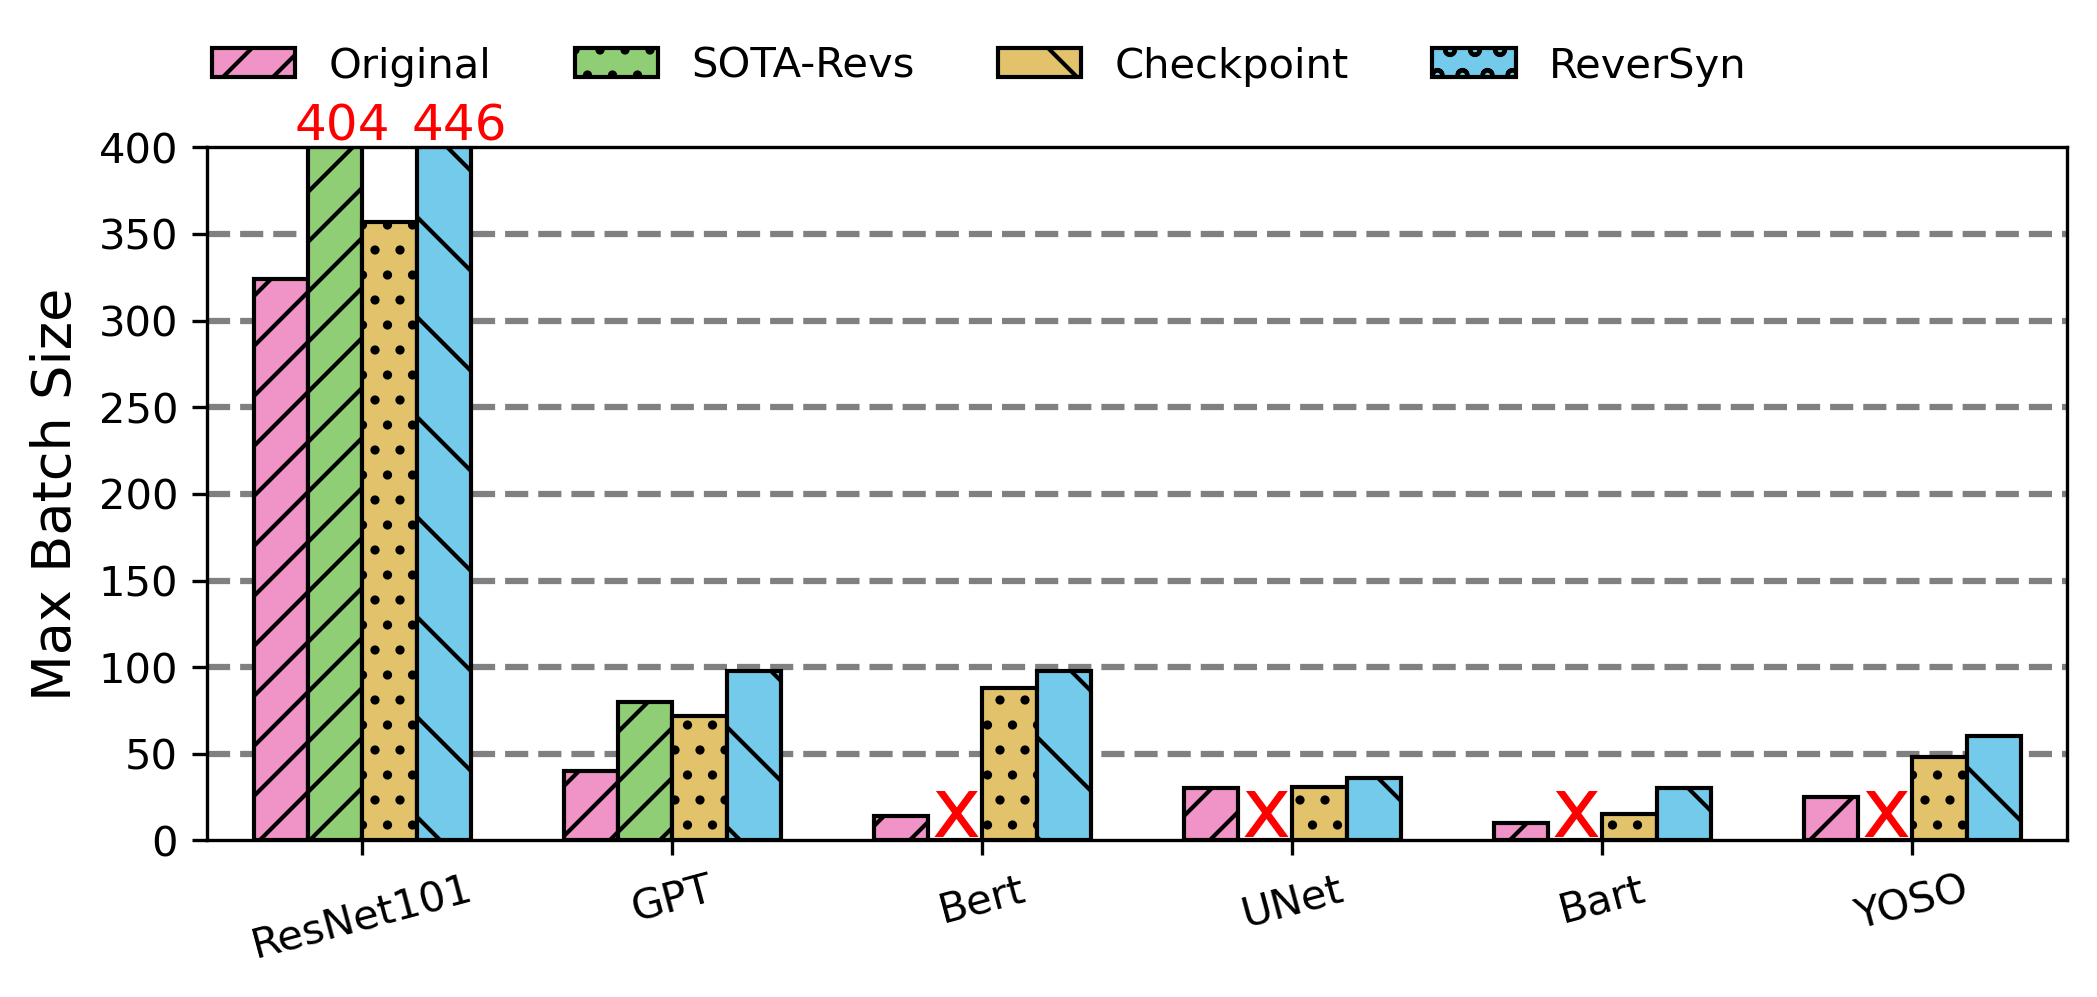

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300

colors = ["#FF85CA", "#8ADD67", "#F6CC58", "#60D3FF", "#2e578c"]
#colors = ['#F4B183', '#FFD966', '#BDD7EE', '#C5E0B4']
sns.set_palette(colors)

hatches = ["//", "..", "\\", "oo"]

plt.rcParams["figure.figsize"] = (8, 3)
ax = sns.barplot(data, x="model", y="batch_size", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black", alpha=1.0, width=0.7)

plt.xlabel(None)
plt.ylabel("Max Batch Size", fontsize=13)
legend = plt.legend(loc="upper center", bbox_to_anchor=(0.415, 1.2), ncols=4, frameon=False)

for patch, hatch in zip(legend.get_patches(), hatches):
    patch.set_hatch(hatch)
    patch.set_edgecolor("black")

plt.xticks(rotation=15)
plt.ylim(0, 400)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(model_names)])
    bar.set_edgecolor("black")
    
for y in [50 * i for i in range(1, 8)]:
    ax.axhline(y=y, color="gray", linestyle="--", zorder=0, alpha=1)
    
manual_indices = [8, 9, 10, 11]
for index in manual_indices:
    bar = ax.patches[index]
    plt.text(bar.get_x() + 0.01, 2, "x", color="red", fontsize=20)
    
# resnet101
#bar = ax.patches[18]
plt.text(-0.22, 404, f'404', color="red", fontsize=12)
plt.text(+0.16, 404, f'446', color="red", fontsize=12)

plt.savefig("maxbs-final.pdf", format="pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)